# Regional Revenue Distribution
**Core Pattern:** Multi-Table Relational Joins & Whitelist Filtering

Broadcast-join trips to the zone lookup, roll up by borough. Polars is run in both default and streaming mode; DuckDB is run in both default and internally memory-capped mode.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=True,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped
  Large run: 24 months, cap = 1024 MB (physical RSS)
----------------------------------------------------


## Analytics Functions

In [2]:
NON_BOROUGH = ["Unknown", "N/A"]  # broadcast join: large fact x tiny dimension
TRIP_COLS = ["PULocationID", "total_amount"]
LOOKUP_COLS = ["LocationID", "Borough"]


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def spatial_join_pandas(file_path, lookup_path):
    import pandas as pd

    df_trips = pd.concat(
        [pd.read_parquet(p, columns=TRIP_COLS) for p in file_path],
        ignore_index=True,
    )
    df_lookup = pd.read_csv(lookup_path, usecols=LOOKUP_COLS)
    df_lookup = df_lookup.loc[
        ~df_lookup["Borough"].isin(NON_BOROUGH), LOOKUP_COLS
    ].copy()
    if len(df_trips):
        df_lookup["LocationID"] = df_lookup["LocationID"].astype(
            df_trips["PULocationID"].dtype
        )

    merged = pd.merge(
        df_trips,
        df_lookup,
        left_on="PULocationID",
        right_on="LocationID",
        how="inner",
        copy=False,
    )
    result = (
        merged.groupby("Borough", sort=True)
        .agg(total_trips=("Borough", "size"), total_revenue=("total_amount", "sum"))
        .reset_index()
        .copy()
    )
    return result, {"engine": pd.__name__, "version": pd.__version__}


def spatial_join_polars(file_path, lookup_path):
    import polars as pl

    trips = pl.scan_parquet(file_path).select(
        [
            pl.col("PULocationID").cast(pl.Int64),
            pl.col("total_amount"),
        ]
    )
    lookup = (
        pl.scan_csv(lookup_path)
        .select([pl.col("LocationID").cast(pl.Int64), pl.col("Borough")])
        .filter(~pl.col("Borough").is_in(NON_BOROUGH))
    )
    lf = (
        trips.join(lookup, left_on="PULocationID", right_on="LocationID", how="inner")
        .group_by("Borough")
        .agg(
            [
                pl.len().alias("total_trips"),
                pl.col("total_amount").sum().alias("total_revenue"),
            ]
        )
    )
    result = lf.collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def spatial_join_polars_streaming(file_path, lookup_path):
    import polars as pl

    trips = pl.scan_parquet(file_path).select(
        [
            pl.col("PULocationID").cast(pl.Int64),
            pl.col("total_amount"),
        ]
    )
    lookup = (
        pl.scan_csv(lookup_path)
        .select([pl.col("LocationID").cast(pl.Int64), pl.col("Borough")])
        .filter(~pl.col("Borough").is_in(NON_BOROUGH))
    )
    lf = (
        trips.join(lookup, left_on="PULocationID", right_on="LocationID", how="inner")
        .group_by("Borough")
        .agg(
            [
                pl.len().alias("total_trips"),
                pl.col("total_amount").sum().alias("total_revenue"),
            ]
        )
    )
    result = lf.collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def spatial_join_duckdb(file_path, lookup_path):
    import duckdb

    query = """
        WITH lookup AS (
            SELECT LocationID, Borough
            FROM read_csv_auto($lookup)
            WHERE Borough NOT IN ('Unknown', 'N/A')
        )
        SELECT
            l.Borough,
            COUNT(*) AS total_trips,
            SUM(t.total_amount) AS total_revenue
        FROM read_parquet($files) t
        JOIN lookup l ON t.PULocationID = l.LocationID
        GROUP BY 1
    """
    result = _duckdb_materialize(
        query,
        {"files": list(map(str, file_path)), "lookup": lookup_path},
    )
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def spatial_join_duckdb_capped(file_path, lookup_path):
    import duckdb

    query = """
        WITH lookup AS (
            SELECT LocationID, Borough
            FROM read_csv_auto($lookup)
            WHERE Borough NOT IN ('Unknown', 'N/A')
        )
        SELECT
            l.Borough,
            COUNT(*) AS total_trips,
            SUM(t.total_amount) AS total_revenue
        FROM read_parquet($files) t
        JOIN lookup l ON t.PULocationID = l.LocationID
        GROUP BY 1
    """
    result = _duckdb_materialize(
        query,
        {"files": list(map(str, file_path)), "lookup": lookup_path},
        capped=True,
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def _coerce_lookup_for_dask(df_lookup, df_trips):
    dtype = df_trips._meta["PULocationID"].dtype
    out = df_lookup.loc[~df_lookup["Borough"].isin(NON_BOROUGH), LOOKUP_COLS].copy()
    out["LocationID"] = out["LocationID"].astype(dtype)
    return out


def spatial_join_dask(file_path, lookup_path):
    import dask
    import dask.dataframe as dd
    import pandas as pd

    df_trips = dd.read_parquet(file_path, columns=TRIP_COLS)
    df_lookup = _coerce_lookup_for_dask(
        pd.read_csv(lookup_path, usecols=LOOKUP_COLS), df_trips
    )
    merged = df_trips.merge(
        df_lookup, left_on="PULocationID", right_on="LocationID", how="inner"
    )
    result = (
        merged.groupby("Borough")
        .agg(total_trips=("Borough", "size"), total_revenue=("total_amount", "sum"))
        .reset_index()
        .compute()
    )
    return result, {"engine": dask.__name__, "version": dask.__version__}


def spatial_join_daft(file_path, lookup_path):
    import daft
    from daft import col

    df_trips = daft.read_parquet(list(file_path)).select("PULocationID", "total_amount")
    df_lookup = (
        daft.read_csv(lookup_path)
        .select("LocationID", "Borough")
        .filter(~col("Borough").is_in(NON_BOROUGH))
    )
    merged = df_trips.join(df_lookup, left_on="PULocationID", right_on="LocationID")
    result = (
        merged.groupby("Borough")
        .agg(
            [
                daft.lit(1).count().alias("total_trips"),
                col("total_amount").sum().alias("total_revenue"),
            ]
        )
        .collect()
    )
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    spatial_join_pandas,
    spatial_join_polars,
    spatial_join_polars_streaming,
    spatial_join_duckdb,
    spatial_join_duckdb_capped,
    spatial_join_dask,
    spatial_join_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(
    ANALYTICS, target_cols=["Borough", "total_trips", "total_revenue"], pass_lookup=True
)
reporter.export_results(
    suite_id="03",
    title="Regional Revenue Distribution",
    core_pattern="Multi-Table Relational Joins & Whitelist Filtering",
    description="Broadcast-join 24 months of trips to the zone lookup, roll up by borough. Polars: default vs. streaming. DuckDB: default vs. memory-capped.",
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3              237 ms  peak 1349 MB


    polars v1.41.2              47 ms  peak 448 MB


    polars-streaming v1.41.2      19 ms  peak 290 MB


    duckdb v1.5.4               38 ms  peak 155 MB


...

    polars-streaming v1.41.2     471 ms  peak 614 MB


    duckdb v1.5.4              441 ms  peak 253 MB


    duckdb-capped v1.5.4       406 ms  peak 246 MB


    dask v2026.6.0                OOM  peak 1104 MB


    daft v0.7.15              1290 ms  peak 480 MB
    → consistency: ✅ 4 engine(s) agree (6 rows)
📊 exported suite [03] → public/benchmark_results.json


## Analysis

/var/folders/b4/zgrb44r15zj1x3shp5gzh5wr0000gn/T/ipykernel_63581/3274009087.py:36: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  merged = pd.merge(


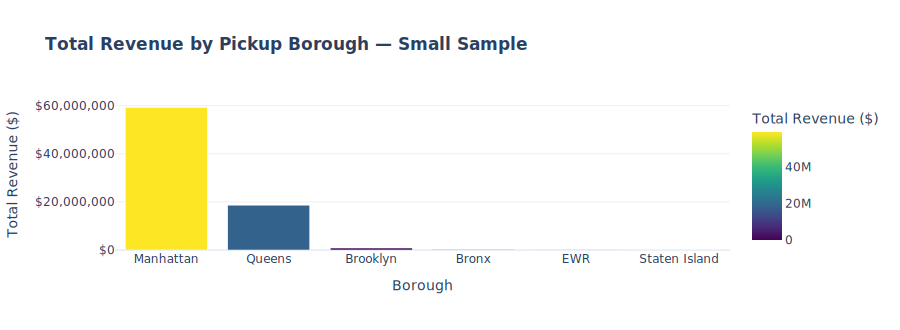

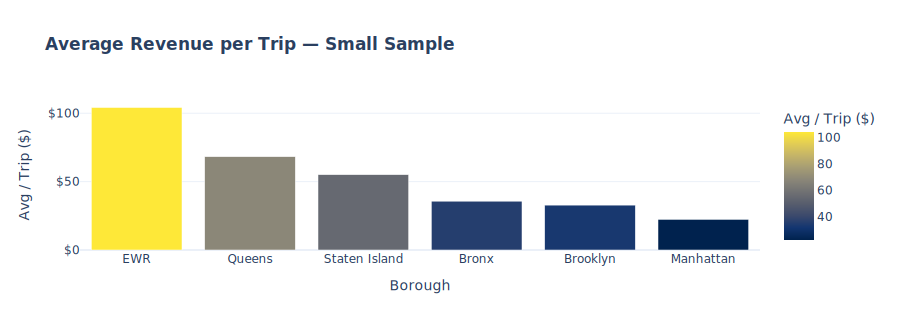

In [4]:
import plotly.express as px

# Visualization is intentionally standardized through pandas on the small run.
reporter.set_analysis_fn(spatial_join_pandas, mode="small", pass_lookup=True)
df = reporter.get_analysis_df(["Borough", "total_trips", "total_revenue"])
df["avg_per_trip"] = df["total_revenue"] / df["total_trips"]
fig = px.bar(
    df.sort_values("total_revenue", ascending=False),
    x="Borough",
    y="total_revenue",
    color="total_revenue",
    title="<b>Total Revenue by Pickup Borough — Small Sample</b>",
    labels={"total_revenue": "Total Revenue ($)"},
    color_continuous_scale="Viridis",
)
fig.update_layout(
    template="plotly_white",
    yaxis_tickformat="$,",
    showlegend=False,
    width=900,
    height=330,
)
fig.show()
fig2 = px.bar(
    df.sort_values("avg_per_trip", ascending=False),
    x="Borough",
    y="avg_per_trip",
    color="avg_per_trip",
    title="<b>Average Revenue per Trip — Small Sample</b>",
    labels={"avg_per_trip": "Avg / Trip ($)"},
    color_continuous_scale="Cividis",
)
fig2.update_layout(
    template="plotly_white",
    yaxis_tickformat="$,",
    showlegend=False,
    width=900,
    height=330,
)
fig2.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Multi-Table Spatial Join Performance")

#### Multi-Table Spatial Join Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.2371s | 1.2×       | 1349 MB    | —        |
| daft v0.7.15             | 0.0570s | 5.0×       | 200 MB     | —        |
| dask v2026.6.0           | 0.2860s | 1.0×       | 1189 MB    | —        |
| duckdb v1.5.4            | 0.0378s | 7.6×       | 155 MB     | —        |
| duckdb-capped v1.5.4     | 0.0379s | 7.5×       | 154 MB     | —        |
| polars v1.41.2           | 0.0466s | 6.1×       | 448 MB     | —        |
| polars-streaming v1.41.2 | 0.0185s | **15.5×**  | 290 MB     | —        |

*✅ 7 engine(s) agree (6 rows)*

#### Multi-Table Spatial Join Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1061 MB   | ≥1.04    |
| daft v0.7.15             | 1.2896s | 1.0×       | 480 MB     | 0.47     |
| dask v2026.6.0           | **OOM** | —          | ≥1104 MB   | ≥1.08    |
| duckdb v1.5.4            | 0.4410s | 2.9×       | 253 MB     | 0.25     |
| duckdb-capped v1.5.4     | 0.4062s | **3.2×**   | 246 MB     | 0.24     |
| polars v1.41.2           | **OOM** | —          | ≥1040 MB   | ≥1.02    |
| polars-streaming v1.41.2 | 0.4707s | 2.7×       | 614 MB     | 0.60     |

*✅ 4 engine(s) agree (6 rows)*